Full Stack Deep Learning 01  
Last modified : 2026.04  
제작 : 박광석 (모두의연구소)  

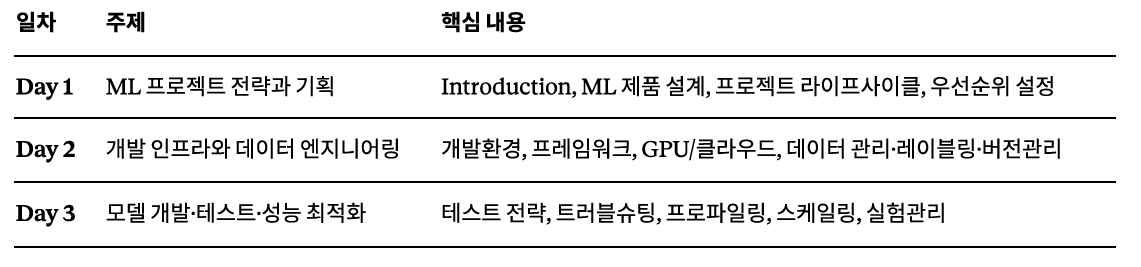


---

# Day 1. ML 프로젝트 전략과 기획

---



## Chapter 0. Introduction — 모델 배포, MLOps, 그리고 Full Stack Deep Learning


### 0.1 여러분이 지금까지 걸어온 길

여러분은 이미 긴 여정을 거쳐 이 자리에 와 있습니다. 머신러닝과 딥러닝의 수학적 기초부터 시작하여, Transformer 아키텍처와 주요 모델 구조를 학습했고, LLM의 3단계(Pretrain → Fine-tuning → Human Alignment)를 직접 실습했습니다. 나아가 RAG와 Agent까지 구현해 보았으며, 가장 최근에는 REST API, FastAPI, Streamlit을 활용한 **모델 배포(Model Serving)** 까지 경험했습니다.

즉, 여러분은 이미 "모델을 만들고, 사용자가 접근할 수 있는 형태로 서빙하는" 능력을 갖추고 있습니다.

**그렇다면 이 과정은 왜 필요할까요?**


### 0.2 배포 이후의 세계: "Done"은 없다

모델을 FastAPI로 감싸 엔드포인트를 만들고 Streamlit으로 데모를 만드는 것은 ML 제품의 **시작점**에 불과합니다. 실제 프로덕션 환경에서는 다음과 같은 질문들이 즉시 쏟아집니다:

- 모델의 정확도가 시간이 지나며 떨어지고 있다 — **어떻게 감지하고 대응할 것인가?**
- 학습 데이터와 실제 서비스 데이터의 분포가 다르다 — **Data Drift를 어떻게 관리할 것인가?**
- 새로운 데이터가 매일 쌓이고 있다 — **재학습 파이프라인을 어떻게 자동화할 것인가?**
- 팀이 3명에서 10명으로 늘었다 — **실험 결과와 데이터 버전을 어떻게 공유할 것인가?**
- GPT-4o급 API가 등장했다 — **직접 학습할 것인가, API를 쓸 것인가?**

이 질문들은 크게 두 가지 영역으로 나뉩니다: **ML Powered Product의 설계**와 **MLOps 인프라의 구축**입니다.



### 0.3 세 가지 축: 모델 배포 → Full Stack DL → MLOps

여러분의 학습 여정을 하나의 파이프라인으로 보면, 지금 여러분은 정확히 가운데에 서 있습니다.


[이전 과정] 모델 배포 개론
- REST API / FastAPI
- Streamlit
- 모델 서빙 기초

[현재 과정] Full Stack Deep Learning
- ML 프로젝트 전략 · 기획
- 개발 인프라 · 데이터 관리
- 모델 테스트 · 트러블슈팅 · 최적화
- 실험 관리 · 스케일링

[다음 과정] MLOps
- Docker
- GCP / BigQuery
- Airflow / Vertex AI
- CI/CD 파이프라인


**모델 배포 개론** 은 "학습된 모델을 사용자에게 전달하는 인터페이스"에 집중했습니다.  
즉, 모델이 이미 완성되어 있다는 전제 하에 서빙 방법을 다루었습니다.

**Full Stack Deep Learning(본 과정)** 은 그 전제 자체를 의심합니다.  
"그 모델이 정말 올바른 문제를 풀고 있는가?", "데이터는 신뢰할 수 있는가?", "실험은 재현 가능한가?", "성능이 떨어졌을 때 원인을 어떻게 추적하는가?" — 모델의 **생애 전체**를 관리하는 엔지니어링 사고방식을 다룹니다.

**MLOps(다음 과정)** 는 이 사고방식을 실제 인프라로 구현합니다.  
Docker로 환경을 격리하고, GCP 위에 파이프라인을 올리며, Airflow로 워크플로우를 자동화하고, CI/CD로 모델을 지속적으로 배포합니다.



### 0.4 ML Powered Product vs. MLOps — 겹치지만 다른 지향점

이 두 개념은 자주 혼동되지만, 초점이 다릅니다.

**MLOps**는 모델의 배포·유지보수·운영에 관한 규율입니다. 인프라, 확장성, 자동화에 집중합니다. "모델을 안정적으로 서빙하고 재학습시키는 파이프라인을 어떻게 만들 것인가?"가 핵심 질문입니다.

**ML Powered Product**는 인프라를 넘어 제품의 맥락에서 ML을 바라봅니다:
- 사용자가 모델과 어떻게 상호작용하는가?
- ML 시스템을 위해 팀과 조직을 어떻게 구성하는가?
- 데이터 레이블링과 사용자 피드백 캡처를 제품 설계에 어떻게 녹여내는가?
- Foundation Model API를 쓸 것인가, 자체 모델을 학습할 것인가?

본 과정(FSDL)은 **ML Powered Product** 관점에서 프로젝트 전체를 조망하되, 후속 과정(MLOps)에서 깊이 다룰 인프라 토픽은 의도적으로 남겨둡니다.



### 0.5 "평평한 지구 ML" vs. "둥근 지구 ML"



학계나 학습 과정에서 접하는 ML 워크플로우는 직선적(Linear)입니다:




이것을 **"평평한 지구 ML(Flat Earth ML)"** 이라고 부릅니다. 모델이 좋은 성능을 내면 프로젝트가 끝난 것으로 간주합니다.

하지만 실제 세계는 **"둥근 지구(Round Earth)"** 입니다:


📌 선형적 ML 워크플로우 (Linear ML Workflow)
1. 순서도 형태 (콜아웃이나 인용구 블록에 넣기 좋습니다)

    - 문제 정의 ➔ 데이터 수집 ➔ 모델 학습 ➔ 평가 ➔ 논문/노트북 작성 ➔ Done!

2. 리스트 형태 (각 항목 아래에 세부 내용을 작성할 때 좋습니다)

    - 문제 정의

    - 데이터 수집

    - 모델 학습

    - 평가

    - 논문/노트북 작성

    - Done!


🔄 [연속적인 피드백 루프] 모델 라이프사이클 관리
1. 순환 구조 형태 (인용구 블록 활용 추천)

    - 기획 ➔ 데이터 ➔ 학습 ➔ 배포 ➔ 단계 사용자 피드백 / 새 데이터 ➔ 모니터링 ➔ (다시 '기획'으로 반복)

2. 리스트 형태 (세부 내용을 작성할 때 추천)

    - 기획

    - 데이터

    - 학습

    - 배포

    - 단계 사용자 피드백 / 새 데이터

    - 모니터링

모델을 배포하는 순간 **외부 루프(Outer Loop)** 가 시작됩니다. 실제 사용자의 데이터가 모델을 개선하고, 개선된 모델이 더 많은 사용자를 끌어들이는 **데이터 플라이휠(Data Flywheel)** 이 돌아갑니다. 이 순환 구조를 설계하고 관리하는 것이 Full Stack ML 엔지니어의 핵심 역량입니다.



### 0.6 급변하는 ML 생태계: 현재의 지형도

불과 몇 년 전만 해도 ML 제품은 빅테크의 전유물이었고, GPT-1 수준의 모델도 적용이 까다로웠습니다. 지금은 완전히 다른 세계입니다.

**Foundation Model의 지배적 부상**
GPT-4o, Claude, Gemini, Llama 3 등 다양한 Foundation Model이 API로 즉시 사용 가능하며, 많은 ML 프로젝트는 "처음부터 모델을 학습할 것인가, API를 활용할 것인가"라는 선택지에서 시작합니다.

**LLM 기반 애플리케이션 아키텍처의 등장**
- RAG(Retrieval-Augmented Generation), Agent, Tool Use 같은 패턴이 표준화되었습니다.
- 여러분이 이미 학습한 이 개념들은 이제 ML 제품의 기본 빌딩 블록입니다.

**ML 엔지니어의 역할 재정의**
- 2022년: "모델을 학습시키고 최적화하는 사람"
- 2026년: "Foundation Model 위에 제품을 설계하고, 필요할 때 자체 모델을 Fine-tuning하며, 전체 시스템의 데이터 플라이휠을 관리하는 사람"

**Evaluation과 Observability의 중요성 급증**
- LLM 기반 시스템은 전통적인 정확도 메트릭만으로 평가할 수 없습니다.
- Human evaluation, LLM-as-a-Judge, 프롬프트 품질 모니터링 등 새로운 평가 패러다임이 등장했습니다.



### 0.7 본 과정에서 다루는 것

앞으로 3일간, 여러분들은 다음 내용을 확인하시게 됩니다.  
- ML 프로젝트를 처음부터 끝까지 기획하는 전략적 프레임워크
- "ML이 필요한가?"라는 근본적 질문에 답하는 의사결정 방법론
- 개발 환경, 프레임워크, GPU 선택의 실무적 가이드
- 데이터 수집·레이블링·버전 관리의 체계적 접근법
- 모델 테스트와 트러블슈팅의 단계적 전략
- 실험 관리와 성능 최적화 기법
- 2026년 기준 최신 도구와 생태계 업데이트


### 0.8 3일간의 로드맵

**Day 1 — 전략과 기획: "무엇을 만들 것인가"**
ML 프로젝트의 성패는 코드가 아니라 기획에서 결정됩니다. ML 도입 여부 판단, 우선순위 설정, 프로젝트 라이프사이클 이해, 제품 아키타입 선정까지 — 첫 줄의 코드를 쓰기 전에 답해야 할 질문들을 다룹니다.

**Day 2 — 인프라와 데이터: "어떻게 만들 것인가"**
개발 환경 구축, 프레임워크 선택, GPU와 클라우드 활용법, 그리고 데이터 수집부터 레이블링, 버전 관리까지 — ML 프로젝트의 "보이지 않는 90%"를 체계적으로 정리합니다.

**Day 3 — 테스트와 최적화: "어떻게 신뢰할 것인가"**
모델이 구동되게 만들고(Make it run), 빠르게 만들고(Make it fast), 올바르게 만드는(Make it right) 3단계 트러블슈팅 전략을 학습합니다. 실험 관리, 스케일링 법칙, 그리고 Foundation Model 활용 전략까지 다룹니다.



> **✅ Chapter 0 체크포인트**
> 1. 모델 배포(FastAPI/Streamlit)와 Full Stack DL, 그리고 MLOps는 각각 어떤 범위를 담당하며, 왜 세 과정이 분리되어야 하는지 설명할 수 있으신가요?
> 2. "평평한 지구 ML"과 "둥근 지구 ML"의 차이를 동료에게 30초 안에 설명할 수 있으신가요? 데이터 플라이휠은 이 비유에서 어디에 해당하나요?
> 3. ML Powered Product와 MLOps의 지향점 차이를 구체적인 질문 하나씩으로 대비할 수 있으신가요?



---

## Chapter 1. ML 제품의 가치와 현대 ML 생태계의 지형도



### 1.1 2026년의 ML 풍경: 기술의 범용화(Commoditization)

2018년만 해도 ML 제품은 구글, 메타 같은 빅테크의 전유물이었습니다. GPT-1 수준의 모델조차 코드가 복잡하고 표준화가 부족하여 적용하기 어려웠습니다.

2026년 현재, 상황은 완전히 달라졌습니다:

**모델 학습의 범용화**: 과거에는 수백 줄의 복잡한 코드가 필요했던 최첨단 모델 활용이 Hugging Face의 `transformers` 라이브러리를 통해 단 몇 줄로 가능해졌습니다.

```python
from transformers import pipeline

# 감성 분석 모델을 즉시 활용 — 직접 설계할 필요 없음
classifier = pipeline("sentiment-analysis")
result = classifier("Full Stack Deep Learning is essential for ML engineers!")
print(result)  # [{'label': 'POSITIVE', 'score': 0.9998}]
```

**Model-as-a-Service의 폭발적 성장**: OpenAI API, Anthropic API, Google Vertex AI 등을 통해 모델을 직접 학습하지 않고도 API 호출 한 번으로 최첨단 성능을 활용할 수 있게 되었습니다. 이는 ML 엔지니어의 역할을 "모델을 만드는 사람"에서 "모델을 제품에 통합하는 사람"으로 확장시켰습니다.

**오픈소스 생태계의 성숙**: Llama 3, Mistral, Qwen 등 오픈소스 Foundation Model의 성능이 상용 API에 근접하면서, 비용·보안·커스터마이징 측면에서 자체 호스팅을 선택하는 팀도 늘어나고 있습니다.



### 1.2 Software 2.0 — 왜 ML 제품이 특별한가



Andrej Karpathy가 제안한 **Software 2.0** 개념은 오늘날 더욱 현실적으로 와닿습니다.

**Software 1.0**: 프로그래머가 명시적인 코드(if-else 로직)를 작성합니다. 입력과 출력 사이의 관계를 사람이 직접 정의합니다.

**Software 2.0**: 최적화 알고리즘(Gradient Descent)이 데이터를 바탕으로 코드를 '작성'합니다. 프로그래머는 데이터와 목적 함수를 정의하고, 모델이 스스로 입출력 관계를 학습합니다.

Full Stack Deep Learning은 이 Software 2.0을 실제 **제품**으로 관리하는 방법을 다룹니다. 전통적인 소프트웨어와 달리, ML 제품은 코드뿐 아니라 **데이터의 품질과 분포**에 의해 동작이 결정되기 때문에, 근본적으로 다른 개발·테스트·운영 전략이 필요합니다.



### 1.3 기술적 부채(Technical Debt) — ML 시스템이 빠지는 함정



Google의 유명한 논문 "Hidden Technical Debt in Machine Learning Systems"에 따르면, ML 시스템은 기존 소프트웨어보다 기술적 부채를 훨씬 빠르게 축적합니다.

**CACE 현상 (Changing Anything Changes Everything)**
모델의 한 파라미터나 데이터 입력 하나를 바꾸면 전체 시스템의 예측 결과가 예측 불가능하게 변합니다. 컴포넌트 간의 경계가 침식되어 독립적인 테스트와 유지보수가 극도로 어려워집니다.

**데이터 의존성의 비용**
코드 수정은 diff로 추적할 수 있지만, 데이터 파이프라인의 미세한 변화(예: 크롤링 소스 하나의 포맷 변경)가 전체 모델 성능을 무너뜨릴 수 있습니다. 이를 추적하고 롤백하는 비용은 코드 변경보다 훨씬 높습니다.

**외부 세계의 불안정성**
사용자의 행동 변화, 계절적 요인, 사회적 트렌드 등으로 입력 데이터의 분포가 끊임없이 변합니다(Data Drift). 이는 전통적 소프트웨어에서는 거의 발생하지 않는 문제입니다.

> **핵심 교훈**: ML 도입은 "기능 하나를 추가하는 것"이 아니라 "지속적으로 관리해야 하는 생물을 키우는 것"에 가깝습니다. 이 부채를 인식하고 관리하는 것이 FSDL의 존재 이유입니다.



> **✅ Chapter 1 체크포인트**
> 1. Software 1.0과 Software 2.0의 근본적인 차이는 무엇이며, 이 차이가 왜 전혀 다른 개발·테스트·운영 전략을 요구하는지 설명할 수 있으신가요?
> 2. CACE 현상(Changing Anything Changes Everything)이 전통적인 소프트웨어에서는 왜 덜 문제가 되고, ML 시스템에서는 왜 치명적인지 정리해 보셨나요?
> 3. "기술의 범용화(Commoditization)"가 ML 엔지니어의 역할을 어떻게 변화시키고 있는지 자신의 언어로 설명할 수 있으신가요?

---



**✅ Chapter 1 체크포인트**
1. Software 1.0과 Software 2.0의 근본적인 차이는 무엇이며, 이 차이가 왜 전혀 다른 개발·테스트·운영 전략을 요구하는지 설명할 수 있으신가요?
    - 근본적인 차이
        - Software 1.0 (명시적 프로그래밍): 사람이 직접 로직과 규칙을 코드로 작성합니다. 개발자가 시스템의 모든 동작 방식을 완전히 통제하고 이해할 수 있습니다.
        - Software 2.0 (기계 학습): 목표(Loss function)와 데이터가 주어지면, 모델이 데이터의 패턴을 학습하여 스스로 규칙(가중치)을 찾아냅니다. 동작 로직은 코드가 아닌 데이터에 의해 결정됩니다.

    - 다른 전략이 요구되는 이유
        - 개발: 과거에는 '코드를 어떻게 더 효율적으로 짤 것인가'가 중요했다면, 이제는 '어떻게 고품질의 데이터를 수집하고 라벨링할 것인가(Data-centric)'로 작업의 중심이 이동합니다.
        - 테스트: 1.0에서는 정해진 입력에 대한 명확한 출력(Unit Test)을 검증합니다. 반면 2.0은 확률적으로 동작하므로, 보지 못한 데이터(Test set)에 대한 성능 평가, 엣지 케이스(Edge case) 분석 등 통계적이고 정성적인 검증이 필요합니다.
        - 운영: 코드는 썩지 않지만, 모델은 시간이 지남에 따라 현실 세계의 데이터 분포가 변하면서(Data Drift) 성능이 저하됩니다. 따라서 배포가 끝이 아니라, 지속적인 모니터링과 데이터 재수집, 재학습을 수행하는 파이프라인(MLOps)이 필수적입니다.

2. CACE 현상(Changing Anything Changes Everything)이 전통적인 소프트웨어에서는 왜 덜 문제가 되고, ML 시스템에서는 왜 치명적인지 정리해 보셨나요?
    - 전통적인 소프트웨어에서 덜 문제가 되는 이유
        - 객체지향 프로그래밍 등을 통해 시스템이 모듈화(Modularity)와 캡슐화(Encapsulation)가 잘 되어 있습니다. A라는 모듈의 내부 로직을 수정해도, 인터페이스만 유지된다면 B라는 독립된 모듈에는 영향을 미치지 않습니다.

    - ML 시스템에서 치명적인 이유
        - 머신러닝 모델 내부의 변수들은 강하게 얽혀(Entangled) 있습니다.
        - 데이터 전처리 방식을 아주 조금 바꾸거나, 하이퍼파라미터 하나를 수정하거나, 새로운 특성(Feature)을 하나만 추가해도 모델이 학습하는 가중치(Weight) 전체의 분포가 완전히 달라집니다.
        - 즉, 시스템의 한 부분을 건드리면 격리된 상태로 유지되지 못하고 모델 전체의 예측 결과와 성능이 예측 불가능하게 변동하므로, 엄격한 버전 관리(코드, 데이터, 모델 모두)와 실험 트래킹이 필요합니다.

3. "기술의 범용화(Commoditization)"가 ML 엔지니어의 역할을 어떻게 변화시키고 있는지 자신의 언어로 설명할 수 있으신가요?
    - 기술의 범용화(Commoditization)란?
        - 과거에는 신경망 아키텍처를 밑바닥부터 설계하고 최적화하는 것이 극소수 전문가들의 고유한 영역이었습니다. 하지만 이제는 강력한 오픈소스 모델, 클라우드 API(OpenAI 등), AutoML 플랫폼이 대중화되어 고성능 알고리즘 자체를 구하는 것은 매우 쉬운 일이 되었습니다.
    - 역할의 변화
        - 알고리즘 개발자 ➔ AI 시스템 아키텍트: 모델의 구조를 깎는 시간보다, 이미 잘 만들어진 모델을 가져와 우리의 비즈니스 문제에 어떻게 적용할지 고민하는 시간이 늘어났습니다.
        - 엔드투엔드(End-to-End) 파이프라인 중심: ML 엔지니어는 단순한 모델링을 넘어, 모델이 먹고 자랄 데이터를 준비하는 데이터 엔지니어링, 모델을 실제 프로덕트에 얹는 소프트웨어 엔지니어링, 그리고 이를 안정적으로 유지 보수하는 인프라/MLOps 역량을 갖춘 Full Stack Deep Learning 관점을 요구받고 있습니다.

## Chapter 2. ML 도입 여부 결정과 우선순위 설정



### 2.1 냉정한 자문: "정말 ML이 필요한가?"

ML 프로젝트의 실패율은 상당히 높습니다.  

주요 실패 원인들:

**기술적 비실현성(Technical Infeasibility)**: 프로젝트 범위 설정이 잘못되어 첫 번째 모델을 만드는 데만 지나치게 오랜 시간이 소요되는 경우.

**프로덕션 전환의 실패**: 리서치 팀의 주피터 노트북에서는 잘 돌아가던 모델이 실제 서비스로 넘어가지 못하는 경우. 여러분이 배운 FastAPI/Streamlit 기술이 이 간극을 메우는 첫 단추였습니다.

**조직 내 공감대 부족**: 모델 성능에 대해 "이 정도면 고객에게 제공해도 된다"는 합의가 이루어지지 않아 프로젝트가 중단되는 경우.

**작은 문제 해결**: 모델의 정확도는 높지만, 비즈니스적으로 의미 없는 사소한 문제를 해결하고 있어 복잡성만 가중시키는 경우.



### 2.2 ML 도입의 판단 기준: 실현 가능성 × 임팩트 매트릭스

ML 프로젝트의 우선순위를 정할 때, 다음 두 축을 기준으로 평가합니다:

**축 1: 기술적 실현 가능성 (Feasibility)**
- 유사한 문제에 대한 학술 논문이나 벤치마크가 존재하는가?
- 양질의 데이터를 충분히 확보할 수 있는가?
- 요구되는 정확도 수준이 현실적인가?
- 기존에 작동하는 휴리스틱/규칙 기반 솔루션이 있는가? (있다면 ML이 이를 개선할 수 있는가?)

**축 2: 비즈니스 임팩트 (Impact)**
- 이 문제가 해결되었을 때 비즈니스에 미치는 영향은 얼마나 큰가?
- ROI가 ML 도입 비용(인력, 인프라, 유지보수)을 정당화하는가?
- 사용자 경험에 눈에 띄는 개선을 가져오는가?

**의사결정 프레임워크:**


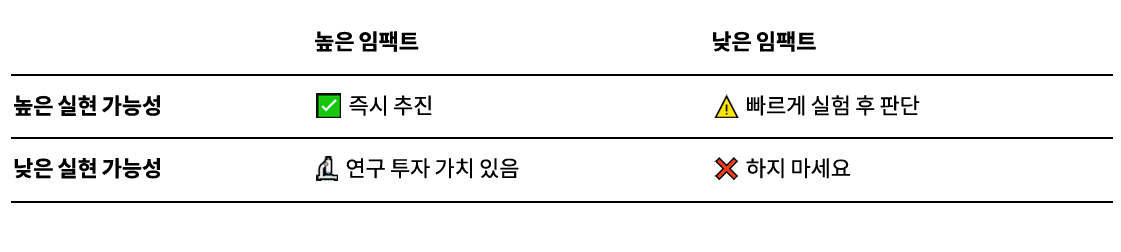


### 2.3 ML 도입 전에 시도해야 할 대안들

ML은 강력하지만 항상 최선의 선택은 아닙니다. ML을 도입하기 전에 다음을 먼저 고려하세요:

1. **규칙 기반 접근법(Rule-based)**: 단순한 if-else 로직이나 정규 표현식으로 80%의 성능을 낼 수 있다면, 이것이 유지보수 비용 면에서 훨씬 경제적일 수 있습니다.

2. **사람의 판단(Human-in-the-loop)**: 의사결정의 정확도가 극도로 중요한 영역(의료 진단, 법률 판단)에서는 ML이 최종 결정자가 아닌 보조 도구로 기능하는 것이 적절할 수 있습니다.

3. **Foundation Model API 활용**: 2026년 현재, 많은 NLP 과제는 GPT-4o나 Claude API를 직접 호출하는 것만으로도 충분한 성능을 낼 수 있습니다. 자체 모델 학습은 API로 해결할 수 없거나, 비용·지연시간·데이터 보안 문제가 있을 때 선택하세요.

4. **전통적 통계 기법**: 회귀 분석, 시계열 분해 등 해석 가능하고 검증된 통계 기법이 문제에 더 적합할 수 있습니다.



### 2.4 2026년의 의사결정 트리: Build vs. Buy vs. API

현대 ML 프로젝트에서 가장 먼저 마주하는 분기점입니다:

```
    "이 문제를 ML로 풀어야 하는가?"
    ├─ No → 규칙 기반 또는 전통 통계 기법 사용
    └─ Yes →
        "Foundation Model API로 충분한가?"
        ├─ Yes → API 활용 (OpenAI, Anthropic, Google 등)
        │         단, 비용·지연시간·데이터 보안을 체크
        └─ No →
            "오픈소스 모델을 Fine-tuning하면 되는가?"
            ├─ Yes → Llama 3, Mistral 등 오픈소스 Fine-tuning
            └─ No → 자체 데이터로 모델 처음부터 학습
```


각 선택지의 트레이드오프는 다음과 같습니다.

| 접근법              | 초기 비용 | 운영 비용  | 커스터마이징 | 데이터 프라이버시        | 지연시간 제어 |
| ---------------- | ----- | ------ | ------ | ---------------- | ------- |
| API 호출           | 매우 낮음 | 사용량 비례 | 제한적    | 낮음 (데이터가 외부로 전송) | 제한적     |
| 오픈소스 Fine-tuning | 중간    | GPU 비용 | 높음     | 높음               | 높음      |
| 처음부터 학습          | 매우 높음 | GPU 비용 | 완전 제어  | 완전 제어            | 완전 제어   |



> **✅ Chapter 2 체크포인트**
> 1. 현재 구상하고 계신 (혹은 관심 있는) ML 프로젝트를 실현 가능성 × 임팩트 매트릭스에 배치해 보셨나요? 어느 사분면에 위치하나요?
> 2. Build vs. Buy vs. API 의사결정 트리에서, "API로 충분한가?"라는 질문에 답하기 위해 구체적으로 무엇을 확인해야 하는지 정리할 수 있으신가요?
> 3. ML을 도입하기 전에 시도해야 할 4가지 대안을 나열하고, 각각이 더 적합한 상황을 예시와 함께 설명할 수 있으신가요?

---




**✅ Chapter 2 체크포인트**
1. 현재 구상하고 계신 (혹은 관심 있는) ML 프로젝트를 실현 가능성 × 임팩트 매트릭스에 배치해 보셨나요? 어느 사분면에 위치하나요?


2. Build vs. Buy vs. API 의사결정 트리에서, "API로 충분한가?"라는 질문에 답하기 위해 구체적으로 무엇을 확인해야 하는지 정리할 수 있으신가요?
    - 성능 (Performance): 프롬프트 엔지니어링과 Few-shot 러닝만으로도 우리가 원하는 수준의 정확도와 결과물이 나오는가?
    - 비용 (Cost): 예상되는 트래픽(API 호출 횟수 및 토큰 수)을 고려했을 때, API 사용료가 비즈니스 마진(ROI)을 훼손하지 않는가?
    - 지연 시간 (Latency): 실시간 처리가 중요한 서비스의 경우, 외부 API를 다녀오는 네트워크 지연(수백 ms ~ 수 초)을 서비스 UX가 감당할 수 있는가?
    - 데이터 보안 및 컴플라이언스 (Data Privacy): 사내 보안 규정이나 개인정보보호법 상, 고객의 민감한 데이터(PII)나 기업 내부 기밀을 외부 클라우드 API로 전송해도 법적인 문제가 없는가?

3. ML을 도입하기 전에 시도해야 할 4가지 대안을 나열하고, 각각이 더 적합한 상황을 예시와 함께 설명할 수 있으신가요?
    - ML 시스템은 유지보수 비용(기술 부채)이 높으므로, 항상 가장 단순한 방법부터 시도해야 합니다.

    1. 휴리스틱 / 규칙 기반 시스템 (Rule-based Heuristics)
        - 설명: 복잡한 학습 대신 단순한 if-else 규칙이나 정규 표현식을 사용합니다.
        - 적합한 상황/예시: 스팸 필터링 초기 단계에서 "당첨", "무료", "100%" 같은 특정 키워드가 포함된 메일을 차단하는 경우. 명확한 비즈니스 로직이 존재할 때 유리합니다.

    2. 전통적인 통계 및 단순 수학 공식
        - 설명: 딥러닝 대신 이동 평균(Moving Average)이나 단순 선형 회귀 등을 활용합니다.
        - 적합한 상황/예시: 변수가 적고 데이터의 패턴이 단순한 경우. 예를 들어, 어제와 그제 매출의 평균을 내어 오늘의 재고를 예측하는 시스템.

    3. UI/UX 개선 (사용자에게 직접 묻기)
        - 설명: 시스템이 힘겹게 예측(Prediction)하는 대신, 디자인을 변경하여 사용자에게 직접 정보(Data)를 입력받습니다.
        - 적합한 상황/예시: 사용자가 어떤 카테고리의 뉴스를 좋아하는지 복잡한 추천 알고리즘으로 예측하기 전에, 온보딩 화면에서 "관심 있는 주제 3가지를 선택해 주세요"라고 직접 묻는 UI를 도입하는 경우.

    4. 인간의 수동 작업 (Wizard of Oz / Human-in-the-loop)
        - 설명: 완전한 자동화 전에, 사람이 백엔드에서 직접 작업을 수행하며 데이터를 쌓고 프로덕트 마켓 핏(PMF)을 검증합니다.
        - 적합한 상황/예시: AI 챗봇 초기 모델을 구축하기 전, 실제 상담원이 챗봇인 척하며 고객 응대 데이터를 수집하고 고객이 이 서비스를 실제로 필요로 하는지 확인하는 경우.



## Chapter 3. ML 프로젝트 라이프사이클


### 3.1 라이프사이클의 4단계와 반복 구조

ML 프로젝트는 선형적으로 진행되지 않습니다. 다음 4단계가 끊임없이 반복됩니다:

**1단계: 프로젝트 기획 및 설정 (Planning & Setup)**
- 프로젝트 수행 여부 결정
- 예산 및 리소스(인력, 컴퓨팅) 할당
- 성공 지표(Metric) 정의
- 윤리적 함의 검토
- 핵심 질문: "우리가 정말 이 문제를 ML로 풀어야 하는가?"

**2단계: 데이터 수집 및 레이블링 (Data Collection & Labeling)**
- 학습에 필요한 데이터 수집 및 정제
- 레이블링 파이프라인 설계 및 품질 관리
- 데이터 증강(Augmentation) 전략 수립
- 반복: 레이블링이 너무 어려우면 → 문제 정의 자체를 수정하여 1단계로 복귀

**3단계: 모델 학습 및 디버깅 (Training & Debugging)**
- 베이스라인(Baseline) 구축
- 최신 모델(SOTA) 적용 및 하이퍼파라미터 튜닝
- 실험 관리 및 결과 비교
- 반복: 데이터 부족이나 레이블 품질 문제 발견 → 2단계로 복귀

**4단계: 배포 및 모니터링 (Deploying & Monitoring)**
- 파일럿 테스트 및 회귀 테스트
- 배포 후 성능 모니터링
- 사용자 피드백 수집
- 반복: 실제 환경에서 성능 급감 → 데이터 미스매치 발견 → 2단계 또는 3단계로 복귀



### 3.2 각 단계에서 발생하는 '되돌아감'의 실제 사례

위 4단계는 깔끔한 순서도처럼 보이지만, 실제로는 거의 모든 프로젝트에서 이전 단계로 되돌아가는 일이 발생합니다. 이 '되돌아감'은 실패가 아니라 ML 프로젝트의 본질적인 특성입니다. 중요한 것은 되돌아감 자체를 방지하는 것이 아니라, 되돌아갈 때의 비용을 최소화하도록 각 단계를 가볍게 설계하는 것입니다.

**4단계 → 2단계 (가장 흔함)**: 오프라인 평가에서는 잘 작동하던 모델이 실제 사용자 환경에서 성능이 급감합니다. 실패 사례를 분석해보면 학습 데이터에 없던 유형의 입력이 대부분입니다. 이 실패 사례들을 수집하여 다시 레이블링하고 학습 데이터에 추가합니다.

**3단계 → 1단계 (고통스러움)**: 모델이 요구하는 정확도(예: 0.1cm 이내)와 서비스가 요구하는 지연시간(예: 10ms 이내)을 동시에 만족하는 것이 불가능할 때, 프로젝트 자체를 재정의해야 합니다.

**2단계 → 1단계 (현명한 판단)**: 데이터 레이블링 비용이 예상보다 10배 높아질 때, "다른 방식으로 문제를 정의하면 더 저렴하게 데이터를 확보할 수 있지 않을까?"라는 질문으로 기획 단계에 복귀합니다.



### 3.3 데이터 플라이휠(Data Flywheel) — 둥근 지구의 핵심 엔진

데이터 플라이휠은 ML 제품이 시간이 지날수록 강해지는 선순환 구조입니다:


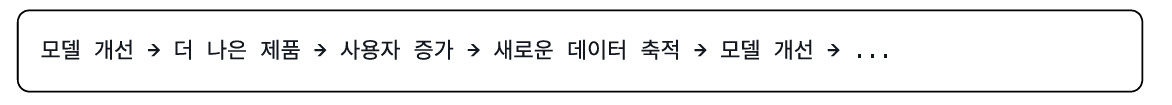


이 플라이휠을 설계할 때 핵심 원칙들:

**사용자 행동 자체가 레이블이 되게 설계하라**: 사용자가 제품을 사용하기만 해도 모델 학습에 유용한 데이터가 생성되어야 합니다. 예를 들어, 추천 시스템에서 사용자의 클릭/스킵이 곧 암묵적 피드백이 됩니다.

**처음부터 거대한 인프라를 구축하지 마라**: "당신은 구글이 아닙니다." 수동으로 일주일에 한 번 데이터를 모아 재학습시키는 것도 훌륭한 초기 단계의 플라이휠입니다.

**성능 저하를 감지하는 루프를 포함하라**: 플라이휠은 성능 향상뿐 아니라, 데이터 분포 변화로 인한 성능 저하를 빠르게 감지하고 대응하는 방어 기제이기도 합니다.



> **✅ Chapter 3 체크포인트**
> 1. ML 프로젝트 라이프사이클 4단계를 순서대로 말할 수 있으신가요? 각 단계의 핵심 활동을 한 문장으로 요약해 보세요.
> 2. "4단계 → 2단계 되돌아감"이 가장 흔한 이유는 무엇이며, 이를 미리 방지하기 위해 기획 단계에서 어떤 질문을 던져야 하는지 생각해 보셨나요?
> 3. 데이터 플라이휠이 자연스럽게 형성되는 제품과 인위적으로 설계해야 하는 제품의 차이를 예시와 함께 설명할 수 있으신가요?

---



**✅ Chapter 3 체크포인트**
1. ML 프로젝트 라이프사이클 4단계를 순서대로 말할 수 있으신가요? 각 단계의 핵심 활동을 한 문장으로 요약해 보세요.
    - 기획 (Scoping & Planning): 풀고자 하는 비즈니스 문제를 정의하고, ML 도입의 타당성(ROI)을 검토하며, 성공을 측정할 평가 지표를 설정합니다.
    - 데이터 (Data): 모델 학습에 필요한 양질의 데이터를 수집, 정제, 전처리하고, 정답지(Label)를 구축합니다.
    - 학습 (Modeling & Training): 적절한 알고리즘(또는 사전 학습 모델)을 선택하여 데이터 패턴을 학습시키고, 실험을 통해 성능을 최적화합니다.
    - 배포 (Deployment & Monitoring): 완성된 모델을 실제 서비스 환경에 적용하고, 지속적인 모니터링을 통해 성능 저하를 감지하며 재학습 파이프라인을 운영합니다.

2. "4단계 → 2단계 되돌아감"이 가장 흔한 이유는 무엇이며, 이를 미리 방지하기 위해 기획 단계에서 어떤 질문을 던져야 하는지 생각해 보셨나요?
    - 가장 흔한 이유: "Training-Serving Skew (학습-서빙 환경의 괴리)"
        - 모델을 실제 환경(4단계)에 배포해 보니, 연구실에서 학습할 때 썼던 데이터(2단계)와 실제 유저들이 입력하는 데이터의 분포나 특성이 완전히 달라서 성능이 곤두박질치는 경우입니다.
        - 또한 사전에 예측하지 못했던 수많은 예외 상황(Edge Case)들이 발생하기 때문에, 결국 이러한 데이터를 다시 수집하고 라벨링하기 위해 2단계로 뼈아픈 회귀를 하게 됩니다.
    - 이를 방지하기 위해 기획(1단계)에서 던져야 할 핵심 질문:
        - "우리가 보유한(또는 수집할) 훈련 데이터가 실제 프로덕션 환경에서 사용자가 만들어낼 데이터를 얼마나 정확히 대변하는가?"
        - "배포 후 예기치 못한 입력이 들어왔을 때, 이를 어떻게 수집하고 라벨링하여 모델을 재학습시킬 것인가? (데이터 파이프라인 유지보수 비용은 계산되었는가?)"


3. 데이터 플라이휠이 자연스럽게 형성되는 제품과 인위적으로 설계해야 하는 제품의 차이를 예시와 함께 설명할 수 있으신가요?
    - 데이터 플라이휠이란 "더 많은 사용자 ➔ 더 많은 데이터 수집 ➔ 모델 성능 향상 ➔ 더 나은 서비스 제공 ➔ 더 많은 사용자 유입"으로 이어지는 선순환 고리를 말합니다.
    - 자연스럽게 형성되는 제품 (암시적 피드백, Implicit Feedback)
        - 특징: 사용자가 서비스를 본래 목적대로 자연스럽게 사용하기만 해도, 그 행동 자체가 모델을 개선할 '정답지(Label)'가 됩니다.
        - 예시 (넷플릭스/유튜브 추천): 사용자가 특정 썸네일을 클릭하고 영상을 끝까지 보았는지, 아니면 5초 만에 이탈했는지(시청 데이터) 자체가 추천 모델이 잘 작동했는지를 알려주는 완벽한 피드백이 됩니다.
    - 인위적으로 설계해야 하는 제품 (명시적 피드백, Explicit Feedback)
        - 특징: 모델이 예측한 결과물을 사용자가 소비하는 것만으로는 그것이 맞았는지 틀렸는지 시스템이 알 수 없습니다. 따라서 UI/UX를 통해 사용자의 평가를 적극적으로 유도해야 합니다.
        - 예시 (ChatGPT, 파파고 번역): 챗봇이나 번역기가 결과를 내놓았을 때, 사용자가 그 글을 그냥 읽고 나갔다면 결과가 좋아서 만족한 것인지 포기한 것인지 알 수 없습니다. 따라서 답변 아래에 '👍(좋아요) / 👎(싫어요)' 버튼을 만들거나, 사용자가 직접 번역을 수정할 수 있는 기능을 제공하여 명시적인 데이터를 수집하도록 제품을 설계해야 합니다.



## Chapter 4. ML 제품의 3가지 아키타입

모든 ML 프로젝트를 동일하게 접근해서는 안 됩니다. 사용자와 상호작용하는 방식, 요구되는 정확도, 비즈니스 임팩트가 프로젝트마다 크게 다르기 때문입니다.



### 4.1 아키타입 1: Software 2.0 (기존 자동화의 개선)

이미 소프트웨어가 수행하는 기존 로직을 ML로 대체하여 더 정확하거나 효율적으로 만드는 유형입니다.

**대표 사례 (2026년 기준)**:
- **IDE 코드 완성**: GitHub Copilot, Cursor 등 AI 코드 어시스턴트
- **추천 시스템**: 넷플릭스·유튜브의 개인화 추천
- **검색 랭킹**: 단순 키워드 매칭에서 의미 기반 검색으로의 전환
- **스팸/사기 탐지**: 규칙 기반에서 패턴 학습 기반으로의 진화

**핵심 질문**:
- 기존 규칙 기반 대비 모델이 실제로 성능을 얼마나 개선하는가?
- 그 개선(예: 정확도 1% 향상)이 ML 도입 비용을 정당화할 만큼 유의미한가?



### 4.2 아키타입 2: Human-in-the-loop (인간의 판단 보조)

인간이 내리는 판단을 ML이 보조하는 방식입니다. 완전 자동화가 아니라 인간의 생산성을 높이는 데 초점을 둡니다.

**대표 사례 (2026년 기준)**:
- **방사선 영상 판독 보조**: AI가 의심 영역을 표시하면 의사가 최종 판단
- **법률 문서 검토**: AI가 관련 조항을 추출하면 변호사가 검토
- **콘텐츠 모더레이션**: AI가 위험 콘텐츠를 필터링하면 리뷰어가 최종 결정
- **AI 코딩 어시스턴트**: AI가 코드를 제안하면 개발자가 수락/수정

**핵심 전략**: 모델의 신뢰도(Confidence)에 따라 자동 처리와 인간 검토를 분기합니다. 신뢰도가 높은 케이스는 자동 처리하고, 낮은 케이스만 인간에게 라우팅하는 것이 효율적입니다.



### 4.3 아키타입 3: Autonomous (완전 자율 시스템)

인간의 개입 없이 ML이 독립적으로 의사결정을 내리는 유형입니다. 가장 높은 정확도와 안전성을 요구합니다.

**대표 사례 (2026년 기준)**:
- **자율주행**: Waymo, Tesla 등의 무인 운전 시스템
- **알고리즘 트레이딩**: 실시간 자동 매매 시스템
- **로봇 자동화**: 물류 센터의 피킹/팩킹 자동화
- **AI Agent**: 복잡한 멀티스텝 태스크를 자율적으로 수행하는 시스템

**핵심 과제**: 안전성 보장과 책임 소재의 명확화. 모델이 틀렸을 때의 비용이 매우 높으므로, 방어적 프로그래밍과 장애 대응(Failover) 설계가 필수적입니다.



### 4.4 아키타입 선택이 프로젝트에 미치는 영향

세 아키타입은 상호 배타적이 아닙니다. 하나의 제품 안에서도 기능별로 서로 다른 아키타입이 공존할 수 있고, 시간에 따라 아키타입이 진화하기도 합니다. 예를 들어 초기에는 Human-in-the-loop으로 시작하여 데이터를 축적한 뒤, 충분한 신뢰도가 확보된 영역부터 점진적으로 Autonomous로 전환하는 것은 매우 흔한 패턴입니다. 아래 표는 각 아키타입을 선택했을 때 프로젝트 전반에 미치는 영향을 비교한 것입니다.


| 관점        | Software 2.0    | Human-in-the-loop | Autonomous  |
| --------- | --------------- | ----------------- | ----------- |
| 모델 정확도 요구 | 기존 대비 개선이면 충분   | 중간 (인간이 보정)       | 매우 높음       |
| 실패의 비용    | 낮음~중간           | 중간 (인간이 방어)       | 매우 높음       |
| 데이터 플라이휠  | 자연스럽게 형성        | 인간 피드백이 핵심        | 시뮬레이션 의존    |
| 출시 속도     | 빠름              | 중간                | 느림          |
| 2026년 트렌드 | LLM API로 빠른 PoC | AI + Human 협업 강화  | Agent 기반 확장 |




> **✅ Chapter 4 체크포인트**
> 1. 세 가지 아키타입(Software 2.0, Human-in-the-loop, Autonomous) 각각에 해당하는 실제 서비스를 하나씩 떠올려 보실 수 있나요?
> 2. 하나의 제품이 처음에는 Human-in-the-loop으로 시작하여 Autonomous로 진화하는 경로를 구체적으로 그려볼 수 있으신가요? 전환의 조건은 무엇일까요?
> 3. 자신이 만들고 싶은 ML 제품은 어떤 아키타입에 해당하며, 그에 따라 모델 정확도·실패 비용·데이터 플라이휠 전략이 어떻게 달라지는지 정리해 보셨나요?

---




**✅ Chapter 4 체크포인트**
1. 세 가지 아키타입(Software 2.0, Human-in-the-loop, Autonomous) 각각에 해당하는 실제 서비스를 하나씩 떠올려 보실 수 있나요?
    - Software 2.0 (보이지 않는 AI): 사용자의 기존 경험(UX)을 크게 바꾸지 않으면서, 백엔드에서 기존의 복잡한 로직을 ML 모델로 대체하는 형태입니다.
        - 예시: 넷플릭스/유튜브의 맞춤형 콘텐츠 추천 알고리즘, 스마트폰의 Face ID, 스팸 메일 필터링.
    - Human-in-the-loop (인간 참여형 / Copilot): AI가 초안을 제시하거나 조언을 제공하지만, 최종 결정과 행동은 사람이 수행합니다. 실패에 대한 리스크를 줄일 수 있습니다.
        - 예시: GitHub Copilot (개발자 코드 자동 완성), Notion AI (글쓰기 초안 작성), 의료진단 보조 소프트웨어 (Lunit 등).
    - Autonomous (완전 자율형 / Agent): AI가 사람의 개입 없이 스스로 판단하고 최종 액션까지 실행합니다. 높은 정확도와 치밀한 예외 처리가 필수적입니다.
        - 예시: Waymo의 완전 자율주행 택시, 알고리즘 기반 초고단타 매매(HFT) 봇, 로봇 청소기.

2. 하나의 제품이 처음에는 Human-in-the-loop으로 시작하여 Autonomous로 진화하는 경로를 구체적으로 그려볼 수 있으신가요? 전환의 조건은 무엇일까요?
    - 처음부터 완벽한 자율형 시스템을 만드는 것은 위험 부담이 큽니다. 많은 서비스가 Human-in-the-loop로 시작하여 점진적으로 자율성을 확보합니다.
    - 진화 경로 예시 (고객 문의 응대 시스템):
        - 초기 (Human-in-the-loop): 고객의 문의가 들어오면 AI가 답변 초안을 작성하여 상담원 화면에 띄워줍니다. 상담원은 이를 수정하거나 승인하여 발송합니다.
        - 데이터 축적 (Flywheel): 상담원이 수정한 데이터는 "AI가 틀렸던 부분"을 명확히 알려주는 최고급 학습 데이터가 됩니다.
        - 진화 (Autonomous): 모델이 점차 고도화되어 특정 유형의 문의(예: 단순 배송 조회, 반품 규정 안내)에 대한 AI의 답변 정확도가 99%를 넘어서면, 해당 카테고리에 한정하여 AI가 직접 답변을 발송(Autonomous)하기 시작합니다.
    - 전환의 핵심 조건:
        - 신뢰할 수 있는 성과 지표: 단순한 정확도(Accuracy)를 넘어, 오작동 시의 비즈니스 임팩트를 감당할 수 있는 수준의 신뢰성(Reliability) 확보.
        - 실패 비용의 하락: 잘못된 결정을 내렸을 때 시스템이 자동으로 복구할 수 있거나, 비즈니스에 미치는 타격이 적어지는 구조적 안전망(Safeguard) 마련.

3. 자신이 만들고 싶은 ML 제품은 어떤 아키타입에 해당하며, 그에 따라 모델 정확도·실패 비용·데이터 플라이휠 전략이 어떻게 달라지는지 정리해 보셨나요?
    - '이상 거래 탐지 및 자동 환불 승인(FDS) 모델'을 기획한다고 가정해 보겠습니다. 
    - A안: Human-in-the-loop (CS 및 운영 담당자 보조 툴)
        - 모델 정확도: 완벽하지 않아도 됩니다. 80% 정도의 정확도로 '의심스러운 거래'를 1차적으로 필터링만 해줘도 담당자의 업무 시간을 크게 줄입니다.
        - 실패 비용: 낮습니다. AI가 정상 거래를 의심 거래로 잘못 판단(False Positive)하더라도, 담당자가 최종 확인 후 승인하면 되기 때문입니다.
        - 플라이휠 전략: 담당자가 AI의 판단을 기각(Reject)하거나 승인(Accept)하는 클릭 데이터 자체를 실시간 로그로 수집하여 모델 재학습 파이프라인에 연결합니다.
    - B안: Autonomous (완전 자동 환불/차단 시스템)
        - 모델 정확도: 극도로 높아야 합니다(특히 Precision). 정상 고객의 결제를 차단하면 즉각적인 매출 손실과 고객 이탈로 이어집니다.
        - 실패 비용: 매우 높습니다. 따라서 확신도가 99% 이상인 경우에만 자율적으로 처리하고, 조금이라도 불확실하면 사람(CS 팀)에게 에스컬레이션하는 로직이 필수입니다.
        - 플라이휠 전략: 사용자의 후속 행동(차단 후 고객센터 항의 전화 여부, 정상 결제 후 즉각적인 취소 여부 등)을 모니터링하여 암시적(Implicit) 데이터로 시스템을 교정해야 합니다.
   


## Chapter 5. ML 프로젝트 팀 구성과 조직 설계



### 5.1 ML 프로젝트에 필요한 역할들

1. ML 엔지니어 (Applied Scientist)
    - 모델 아키텍처
    - 서빙 인프라
    - 데이터 파이프라인
    - Full Stack

2. 데이터 엔지니어
    - 보이지 않는 영웅
    - 데이터 수집
    - 파이프라인

3. ML Platform 엔지니어
    - 모델 레지스트리
    - 배포 인프라
    - 실험 관리 콘솔

4. 프로덕트 매니저
    - 사용자 가치
    - 기술적 한계

5. 도메인 전문가
    - 전문 지식
    - 데이터
    - 레이블링 가이드라인
    - 모델 결과 타당성 검증


- 성공적인 ML 프로젝트에는 다양한 역할이 협업해야 합니다:

**ML 엔지니어 / Applied Scientist**: 모델 선택·학습·최적화. 데이터 파이프라인과 서빙 인프라까지 다루는 "Full Stack" 역할이 점점 더 요구됩니다.

**데이터 엔지니어**: 데이터 수집·정제·파이프라인 구축. ML 프로젝트에서 "보이지 않는 영웅"입니다.

**ML Platform 엔지니어**: 실험 관리, 모델 레지스트리, 배포 인프라 등 팀 전체가 사용하는 플랫폼을 구축합니다.

**프로덕트 매니저**: ML 기술의 가능성과 한계를 이해하고, 사용자 가치와 기술을 연결하는 다리 역할을 합니다.

**도메인 전문가**: 데이터의 의미를 해석하고, 레이블링 가이드라인을 설계하며, 모델 결과의 타당성을 검증합니다.



### 5.2 2026년의 팀 구성 트렌드

**"풀스택 ML 엔지니어"의 부상**: Foundation Model API의 등장으로, 한 사람이 프로토타입부터 배포까지 처리할 수 있는 범위가 크게 넓어졌습니다. 소규모 팀이 빠르게 실험하고 출시하는 것이 가능해졌습니다.

**프롬프트 엔지니어링의 역할 변화**: 초기에 독립적인 직군으로 주목받았던 "프롬프트 엔지니어"는 이제 ML 엔지니어의 기본 역량으로 흡수되는 추세입니다. 프롬프트 설계는 모델 개발 과정의 일부이지, 독립된 직종이 아닙니다.

**Evaluation 전문가의 등장**: LLM 기반 시스템의 평가는 전통적인 정확도 메트릭으로 충분하지 않습니다. Human evaluation 설계, 평가 데이터셋 큐레이션, LLM-as-a-Judge 파이프라인 구축 등을 담당하는 전문 역할이 점차 중요해지고 있습니다.



### 5.3 조직 설계의 원칙

**작게 시작하고, 검증 후 확장하라**: ML 프로젝트의 첫 번째 목표는 "이 문제를 ML로 풀 수 있다"는 것을 증명하는 것입니다. 3명 이내의 팀으로 2~4주 내에 PoC(Proof of Concept)를 완성하는 것을 목표로 하세요.

**리서치와 프로덕션의 거리를 좁혀라**: 모델을 만드는 사람과 배포하는 사람이 다른 팀이면 마찰이 발생합니다. 여러분이 배운 FastAPI와 Streamlit은 이 거리를 좁히는 도구입니다. 모델을 만든 사람이 직접 데모를 만들어 이해관계자에게 보여줄 수 있어야 합니다.

**데이터 문화를 조직에 심어라**: "데이터 수집과 레이블링은 인턴이 하는 일"이라는 인식을 버려야 합니다. 데이터 품질이 곧 모델 품질이며, 시니어 엔지니어가 데이터 파이프라인에 투자하는 것은 모델 아키텍처를 고민하는 것만큼 중요합니다.




> **✅ Chapter 5 체크포인트**
> 1. ML 프로젝트에 필요한 5가지 역할을 나열하고, "풀스택 ML 엔지니어"가 이 중 어디까지 커버할 수 있는지 설명할 수 있으신가요?
> 2. "리서치와 프로덕션의 거리를 좁혀라"는 원칙이 구체적으로 팀의 일하는 방식에 어떤 변화를 요구하는지 생각해 보셨나요?

---

**✅ Chapter 5 체크포인트**
1. ML 프로젝트에 필요한 5가지 역할을 나열하고, "풀스택 ML 엔지니어"가 이 중 어디까지 커버할 수 있는지 설명할 수 있으신가요?

- 성공적인 ML 프로젝트를 위해서는 비즈니스부터 인프라까지 다양한 영역의 전문성이 필요하며, 일반적으로 다음 5가지 역할로 나뉩니다.
    - 프로덕트 매니저 (PM): ML을 통해 해결할 비즈니스 문제를 정의하고, 사용자 가치를 설계하며, 프로젝트의 ROI를 평가합니다.
    - 도메인 전문가: 해당 비즈니스 영역의 깊은 지식을 바탕으로 데이터의 타당성을 검증하고, 레이블링 가이드라인을 세우며, 모델 결과물의 품질을 판단합니다.
    - 데이터 엔지니어: 모델이 학습할 수 있도록 대규모 데이터를 수집, 저장, 전처리하는 안정적인 파이프라인을 구축합니다.
    - ML 엔지니어 (Applied Scientist): 데이터를 바탕으로 최적의 모델 아키텍처를 설계하고 학습시키며, 성능을 튜닝합니다.
    - ML 플랫폼 엔지니어 (MLOps): 학습된 모델을 실제 서비스에 안정적으로 배포하고, 실험 결과와 모델 버전을 관리하는 인프라를 구축합니다.

- 풀스택 ML 엔지니어의 커버 범위
    - 풀스택 ML 엔지니어는 위 역할 중 기술적 영역인 데이터 엔지니어, ML 엔지니어, ML 플랫폼 엔지니어의 역할을 엔드투엔드(End-to-End)로 커버하는 사람을 뜻합니다.
    - 최근 클라우드 서비스와 MLOps 도구들이 고도화(범용화)되면서, 한 명의 엔지니어가 데이터 수집부터 모델 서빙까지 전체 기술 파이프라인을 구축하고 관리하는 것이 가능해졌습니다.

2. "리서치와 프로덕션의 거리를 좁혀라"는 원칙이 구체적으로 팀의 일하는 방식에 어떤 변화를 요구하는지 생각해 보셨나요?
- 과거에는 데이터 과학자가 주피터 노트북(Jupyter Notebook)에서 연구용 코드로 모델을 만들고(리서치), 이를 소프트웨어 엔지니어에게 넘겨 실서비스용 언어(Java, C++ 등)로 처음부터 다시 짜게 하는(프로덕션) '사일로(Silo)' 방식이 흔했습니다. 이 과정에서 수많은 버그와 지연이 발생했습니다.
- 이 거리를 좁히기 위해 팀의 일하는 방식은 다음과 같이 변해야 합니다.
    - 코드와 환경의 통일: 리서치 단계부터 실서비스 배포를 염두에 두고 작업합니다. 노트북 환경은 빠른 실험용으로만 쓰고, 실제 모델링 코드는 모듈화된 파이썬 스크립트로 작성하며 컨테이너(Docker) 기반으로 환경을 통일하여 "내 컴퓨터에서는 되는데 - 서버에서는 안 되는" 현상을 없앱니다.
    - 엔드투엔드 오너십 부여: '모델을 만드는 사람'과 '서비스에 붙이는 사람'을 엄격하게 분리하지 않습니다. 모델을 개발한 엔지니어가 배포된 모델의 프로덕션 성능 모니터링까지 책임지거나 긴밀하게 관여하여, 성능 저하(Data Drift) 발생 시 즉각적으로 대응할 수 있어야 합니다.
    - 초기 단계부터의 크로스펑셔널 협업: 모델 아키텍처를 결정할 때 정확도만 보는 것이 아니라, 초기 기획 단계부터 서비스의 지연 시간(Latency) 제한, 서버 비용 등을 고려하여 실현 가능한 가벼운 모델을 선택하는 방향으로 소통 방식이 바뀌어야 합니다.




## Chapter 6. ML 프로젝트 기획의 실전 체크리스트



### 6.1 프로젝트 시작 전 필수 질문 10가지

프로젝트의 첫 줄의 코드를 쓰기 전에, 팀 전체가 아래 질문들에 명확히 답할 수 있어야 합니다:

1. **문제 정의**: 이 프로젝트가 해결하는 구체적인 사용자 문제는 무엇인가?
2. **성공 지표**: 성공을 어떤 숫자로 측정할 것인가? (비즈니스 메트릭과 ML 메트릭 모두)
3. **베이스라인**: ML 없이 달성할 수 있는 최선의 성능은 얼마인가?
4. **데이터**: 데이터를 어떻게 확보할 것이며, 양과 질이 충분한가?
5. **라벨**: 정답 데이터(Ground Truth)를 어떻게 얻을 것인가? 비용은?
6. **모델 선택**: 자체 학습 vs. Fine-tuning vs. API 중 무엇이 적절한가?
7. **실패 비용**: 모델이 틀렸을 때의 비용은 어느 정도인가? (아키타입과 연결)
8. **지연시간**: 사용자에게 응답을 돌려주는 데 허용 가능한 최대 시간은?
9. **유지보수**: 모델을 지속적으로 업데이트할 인력과 인프라가 있는가?
10. **윤리**: 이 모델이 특정 집단에 불공정한 영향을 미칠 가능성은 없는가?


### 6.2 PoC(Proof of Concept) 수행 가이드

**목표**: 2~4주 이내에 "이 접근법이 작동한다"는 증거를 확보하는 것.

**PoC 원칙**:
- 전체 데이터가 아닌 샘플 데이터로 시작하세요.
- 복잡한 모델이 아닌 가장 단순한 베이스라인부터 시작하세요.
- 완벽한 파이프라인이 아닌 주피터 노트북으로 충분합니다.
- 핵심 가정(예: "이 데이터로 이 정도 성능이 나온다")을 검증하는 데 집중하세요.

**PoC 종료 조건**:
- 베이스라인 대비 ML 모델의 성능 향상이 유의미한가?
- 확보 가능한 데이터의 양과 질이 본격 개발을 지원하는가?
- 요구되는 지연시간/비용 제약을 충족할 수 있는 아키텍처가 존재하는가?

위 질문 중 하나라도 "아니오"라면, 프로젝트를 재정의하거나 중단하는 것이 현명합니다.







### 6.3 고임팩트 프로젝트를 찾는 4가지 멘탈 모델

기술적으로 실현 가능한 프로젝트 중에서, 비즈니스에 실질적인 변화를 일으킬 수 있는 문제를 골라내기 위한 사고 프레임워크입니다.

**멘탈 모델 1: 예측 비용의 하락 (Economics of AI)**

AI의 본질은 '예측(Prediction)의 비용'을 낮추는 기술입니다. 과거에는 사람이 5분간 고민해서 내리던 판단(예: 이 메일이 스팸인가?)을 이제는 GPU가 수 밀리초 만에 처리합니다. "만약 수많은 전문가를 고용해 실시간으로 예측을 내리게 한다면 어떤 가치가 생길까?"를 고민해보세요. 그 지점이 바로 ML이 투입되어 큰 임팩트를 낼 곳입니다.

2026년 업데이트: Foundation Model API의 등장으로 이 비용은 더욱 급격히 하락했습니다. GPT-4o의 토큰당 비용은 불과 2년 전의 1/10 수준이며, 이는 과거에 경제성이 없던 수많은 활용처를 새롭게 열어주고 있습니다.

**멘탈 모델 2: 마찰(Friction) 감소**

사용자가 직접 정보를 찾아다니거나, 반복적인 판단을 내려야 하는 모든 지점이 ML의 후보지입니다. Spotify의 'Discover Weekly'는 음악 탐색의 마찰을 제거하여 사용자 만족도를 비약적으로 높인 대표적인 성공 사례입니다. 제품 디자인 관점에서 사용자의 수고를 덜어주는 모든 곳에 주목하세요.

**멘탈 모델 3: Software 2.0 — 수동 규칙의 대체**

수천 줄의 복잡하고 지저분한 if-else 규칙 뭉치를 ML로 대체할 수 있는 영역을 찾으세요. 시스템이 훨씬 깔끔해지고 성능이 개선됩니다. 특히 규칙이 너무 많아 사람이 관리할 수 없는 수준에 도달한 시스템(예: 대규모 콘텐츠 필터링, 복잡한 라우팅 로직)은 ML 전환의 최우선 후보입니다.

**멘탈 모델 4: 업계 벤치마킹**

넷플릭스, 구글 같은 빅테크의 기술 블로그뿐 아니라, 초기 스타트업의 사례도 참고하세요. 그들이 ML로 어떤 비즈니스 지표를 개선했는지 학습하는 것은 매우 저평가된 강력한 전략입니다.


### 6.4 ML 프로젝트 비용의 3대 동인

프로젝트의 실현 가능성은 곧 비용과 직결됩니다. 세 가지 핵심 동인을 정확히 이해해야 합니다.

**동인 1: 데이터 가용성 — 가장 치명적인 병목**

데이터가 이미 존재하는가, 아니면 새로 수집해야 하는가? 레이블링에 전문가(의사, 변호사 등)가 필요하다면 비용은 천문학적으로 치솟습니다. 데이터가 얼마나 자주 변하는 성질의 것인지(안정적 vs. 매일 변동)도 장기적인 운영 비용에 큰 영향을 미칩니다.

콜드 스타트(Cold Start) 문제: 제품이 없어서 데이터가 없고, 데이터가 없어서 모델이 안 나오고, 모델이 없어서 제품이 매력 없는 악순환이 발생합니다. 이를 해결하기 위해 초기에는 Human-in-the-loop 아키타입으로 시작하거나, 합성 데이터(Synthetic Data)를 활용하는 전략이 유효합니다.

**동인 2: 정확도 요구사항 — 비용의 비선형적 증가**

ML 프로젝트의 비용은 정확도 요구사항에 대해 슈퍼 리니어(Super-linearly)하게 증가합니다. 매우 거친 가이드라인으로, 정확도에 '9'를 하나 더 추가할 때마다(예: 99% → 99.9%) 비용은 약 10배씩 증가할 수 있습니다.

이것이 아키타입 선택과 직결됩니다:
- 자율주행: 오판의 대가가 치명적이므로 극도로 높은 정확도 필요 → 비용 막대
- 이미지 생성(DALL-E, Midjourney): 수천 장 중 하나만 좋아도 사용자는 만족 → 비용 대비 가치 높음
- 추천 시스템: 한두 번 틀려도 사용자 경험이 약간 나빠질 뿐 → 합리적 비용

**동인 3: 문제의 난이도 — 연구 vs. 엔지니어링**

ML은 근본적으로 연구 성격이 있습니다. 일반적인 소프트웨어는 구현 시간이 예측 가능하지만, ML은 특정 성능을 달성하는 데 얼마나 걸릴지 예측하기 어렵습니다. 프로젝트 비용 산정 시 반드시 **불확실성 예산**을 포함해야 합니다.

난이도 판단의 실용적 휴리스틱:
- 인간이 1초 안에 할 수 있는 일은 ML로도 비교적 쉽습니다 (Andrew Ng의 법칙). 단, 유머·냉소·복잡한 물리적 조작 등은 여전히 매우 어렵습니다.
- 학계에 유사한 논문이 충분히 존재하는지가 가장 중요한 실현 가능성 지표입니다.
- 기술 발전의 속도를 과소평가하지 마세요: 2010년에 "새를 식별하라"는 문제가 연구팀 5년짜리 과제였다면, 지금은 API 호출 한 번이면 됩니다.

### 6.5 실현 가능성 평가의 함정: 기술은 빠르게 변한다



실현 가능성을 평가할 때 가장 위험한 것은 **현재의 기술 수준만을 기준으로 판단하는 것**입니다.

과거에는 불가능하다고 여겨졌지만 지금은 당연한 것들:
- 2010년: 사진 속 물체 인식 → "연구팀 5년 프로젝트"
- 2016년: 바둑에서 인간 챔피언 격파 → "100년 이상 걸릴 것"이라는 1990년대 예측을 뒤엎음
- 2022년: 자연어로 이미지 생성 → 불과 1년 전까지 학계에서도 회의적
- 2024년: 복잡한 코딩 태스크 자동화 → "5년은 더 걸릴 것"이라는 2022년 전문가 예측을 뒤엎음

따라서 엔지니어는 최신 SOTA 연구 결과를 지속적으로 모니터링해야 합니다. 지난주에 불가능했던 것이 이번 주에 논문으로 발표될 수 있습니다. Arxiv, Papers with Code, 주요 컨퍼런스(NeurIPS, ICML, ACL) 프로시딩을 정기적으로 확인하는 것이 Full Stack ML 엔지니어의 필수 습관입니다.

### 6.6 윤리와 책임: ML 시스템의 사회적 영향

기술적 실현 가능성과 비즈니스 임팩트만으로 프로젝트를 결정해서는 안 됩니다. ML 시스템은 사회적 영향을 가지며, 이를 프로젝트 기획 단계에서 반드시 검토해야 합니다.

**편향(Bias)과 공정성(Fairness)**

학습 데이터에 내재된 편향은 모델을 통해 증폭됩니다. 채용, 대출 심사, 법률 판단 등 사람의 삶에 직접적인 영향을 미치는 영역에서는 특히 주의가 필요합니다. 프로젝트 기획 단계에서 "이 모델이 특정 성별, 인종, 연령 집단에 불공정한 결과를 만들 수 있는가?"를 자문하고, 데이터 수집·모델 평가 단계에서 이를 검증할 계획을 수립해야 합니다.

**투명성과 설명 가능성**

모델이 왜 그런 결정을 내렸는지 사용자와 이해관계자에게 설명할 수 있어야 합니다. 특히 규제 산업(금융, 의료, 공공)에서는 모델의 설명 가능성이 법적 요구사항이 될 수 있습니다. Human-in-the-loop 아키타입에서는 이것이 더욱 중요한데, 인간이 모델의 판단을 검토하려면 그 판단의 근거를 이해할 수 있어야 하기 때문입니다.

**개인정보 보호와 데이터 주권**

GDPR, 개인정보 보호법 등 데이터 규제는 전 세계적으로 강화되고 있습니다. "어떤 데이터를 수집할 수 있는가?", "사용자의 동의를 어떻게 얻을 것인가?", "데이터를 얼마나 보관할 것인가?"는 기술적 질문이 아니라 법적·윤리적 질문입니다. 이를 프로젝트 초기에 검토하지 않으면 나중에 전체 시스템을 재설계해야 할 수 있습니다.


### 6.7 "합리적 규모"의 원칙: 도구 페티시즘을 경계하라

ML 프로젝트 기획의 마지막 원칙은 **"당신은 구글이 아니다"** 입니다.

빅테크의 기술 블로그에서 본 화려한 인프라(대규모 Feature Store, 수백 개의 자동 재학습 파이프라인, 실시간 A/B 테스트 프레임워크)를 첫 프로젝트부터 도입하려는 유혹에 빠지지 마세요. 이른바 '도구 페티시즘(Tool Fetishization)'은 프로젝트가 시작도 하기 전에 인프라 구축에 모든 에너지를 소진하게 만듭니다.

올바른 순서:
1. 비즈니스 임팩트를 먼저 증명하세요 (주피터 노트북 + 수동 파이프라인으로 충분).
2. 반복 주기가 병목이 되는 지점에서만 도구를 도입하세요.
3. 팀의 규모와 예산에 맞는 '합리적 수준의 자동화'를 선택하세요.
4. 후속 과정(MLOps)에서 배울 Docker, Airflow, Vertex AI 등은 PoC 이후에 도입해도 늦지 않습니다.

> **✅ Chapter 6 체크포인트**
> 1. 프로젝트 시작 전 필수 질문 10가지 중, 자신의 프로젝트에서 가장 답하기 어려운 3개는 무엇이며 왜 어려운지 정리해 보셨나요?
> 2. 고임팩트 프로젝트를 찾는 4가지 멘탈 모델(예측 비용 하락, 마찰 감소, Software 2.0, 업계 벤치마킹)을 자신의 도메인에 각각 적용해 보실 수 있나요?
> 3. "정확도에 9를 하나 더 추가하면 비용이 10배 증가한다"는 법칙이 자신의 프로젝트에 어떤 의미를 갖는지 생각해 보셨나요? 요구 정확도를 낮출 수 있는 제품 설계 방법은 없을까요?
> 4. "당신은 구글이 아니다"라는 원칙에 비추어, 자신의 프로젝트에서 지금 당장 필요한 도구와 나중에 도입해도 되는 도구를 구분할 수 있으신가요?

---


**✅ Chapter 6 체크포인트**
1. 프로젝트 시작 전 필수 질문 10가지 중, 자신의 프로젝트에서 가장 답하기 어려운 3개는 무엇이며 왜 어려운지 정리해 보셨나요?
    - 6번 모델선택
        - OpenAI와 같은 API를 쓰면 내일 당장 프로토타입을 만들 수 있지만, 트래픽이 늘어날수록 종속성(Lock-in)과 비용이 기하급수적으로 증가합니다. 반면, 자체 모델을 학습(Build)하거나 오픈소스 모델을 미세조정(Fine-tuning)하려면 초기 인프라 구축과 데이터 엔지니어링에 엄청난 리소스가 들어갑니다.
    - 7번 실패비용
        - 과탐지(False Positive, 정상인데 이상으로 판단)와 미탐지(False Negative, 이상인데 정상으로 판단). 이 두 가지 중 어느 쪽이 비즈니스에 더 치명적인지 판단이 어렵다.    
    - 10번 윤리
        - 학습전부터 불균형한 데이터로 학습시키기 전에, 데이터를 입력하기 전, '우리의 과거 데이터 구조에 숨겨진 구조적 불균형은 없는가?'를 의심해야 합니다.
        - 테스트 단계에서 전체 평균 정확도만 보지 말고, 데이터 그룹을 세분화(슬라이싱)하여 특정 성별, 연령, 지역에서만 유독 정확도가 떨어지거나 불이익을 받지 않는지 교차 검증하는 파이프라인을 추가해야 합니다.

2. 고임팩트 프로젝트를 찾는 4가지 멘탈 모델(예측 비용 하락, 마찰 감소, Software 2.0, 업계 벤치마킹)을 자신의 도메인에 각각 적용해 보실 수 있나요?
    - 유통도메인 예시
        1. 예측 비용 하락 (Drop in Prediction Cost):
            - 개념: 만약 '무엇이든 공짜로 예측'할 수 있다면 비즈니스가 어떻게 바뀔까?
            - 적용: 기존에는 창고 레벨의 재고 수요 예측만 했다면, 예측 비용이 낮아짐으로써 '특정 동네의 개별 매장 단위, 시간대별 품목 수요'까지 마이크로하게 발주량을 정확하게 예측하여 폐기율을 극단적으로 낮출 수 있습니다.

        2. 마찰 감소 (Reduce Friction):
            - 개념: 사용자가 목적을 달성하기까지 겪는 단계적 허들을 ML로 어떻게 없앨까?
            - 적용: 고객이 상품의 카테고리를 일일이 찾아 들어가는 대신, 사진 한 장을 올리거나 자연어로 "캠핑장 갈 때 입을 만한 옷"이라고 검색하면 의도에 맞는 상품을 바로 매칭해 주는 시스템(Vector Search)을 도입합니다.

        3. Software 2.0:
            - 개념: 끝없이 늘어나는 if-else 하드 코딩 규칙을 ML 모델로 대체할 수 있는가?
            - 적용: 유통 백엔드의 거대한 골칫거리인 결제 이상 거래 탐지(FDS) 시스템이나 복잡한 할인적용 엔진. 수백 개의 예외 처리 규칙을 유지보수하는 대신, 과거 거래 데이터를 학습한 트리를 통해 확률값으로 제어합니다.

        4 업계 벤치마킹 (Benchmarking):
            - 개념: 선도 기업들이 이미 ML로 해결한 문제를 우리 비즈니스에 가져올 수 있는가?
            - 적용: 아마존의 '예측 배송(Anticipatory Shipping)' 모델을 벤치마킹하여, 특정 지역에서 자주 주문되는 생필품을 고객이 결제하기 전에 미리 지역 물류 센터로 이동시켜 놓는 로직을 구현합니다.

3. "정확도에 9를 하나 더 추가하면 비용이 10배 증가한다"는 법칙이 자신의 프로젝트에 어떤 의미를 갖는지 생각해 보셨나요? 요구 정확도를 낮출 수 있는 제품 설계 방법은 없을까요?
    - 정확도 90%를 99%로 만드는 것보다, 99.0%를 99.9%로 만드는 데 훨씬 더 많은 데이터, 컴퓨팅 파워, 그리고 엔지니어링 시간이 듭니다. 마지막 0.1%의 엣지 케이스(Edge case)를 잡는 것은 기하급수적인 비용을 발생시킵니다.
    - 요구 정확도를 낮추는 제품 설계 방법 (기획의 힘)
        - 이 비용을 회피하려면 시스템이 100% 완벽하지 않아도 사용자가 납득할 수 있도록 '제품을 설계'해야 합니다.
        - N-Best 제공: "이 상품을 당장 사세요"라고 단일 상품을 꽂아주는 대신, "이런 상품들은 어떠세요?"라며 5~10개의 추천 리스트를 보여주면, 모델이 1개를 틀려도 사용자는 실패를 체감하지 못합니다.
        - Human-in-the-loop 활용: 자동 환불 승인 모델을 만들 때, 확신도가 95% 이상인 소액 결제 건만 자율로 처리하고 나머지 애매한 건은 기존처럼 CS 직원의 대시보드로 넘깁니다. ML은 완벽할 필요 없이 직원의 업무량만 80% 줄여주면 성공입니다.

4. "당신은 구글이 아니다"라는 원칙에 비추어, 자신의 프로젝트에서 지금 당장 필요한 도구와 나중에 도입해도 되는 도구를 구분할 수 있으신가요?
    - 만 대의 서버와 수천 명의 ML 엔지니어를 가진 빅테크의 아키텍처를 초기 프로젝트에 그대로 가져오면, 오버엔지니어링(기술 부채)에 짓눌려 시작도 전에 지치게 됩니다.
    - 나중에 도입해도 되는 도구 (Don't need yet):
        - 실시간 피처 스토어 (Real-time Feature Store)
        - 복잡한 쿠버네티스(Kubernetes) 기반의 분산 학습 클러스터
        - 자동화된 대규모 재학습 파이프라인 (완벽한 CI/CD/CT)
        - 초거대 모델의 직접 파인튜닝(Fine-tuning)
    - 지금 당장 필요한 도구 (Do it now):
        - 빠른 가설 검증을 위한 외부 API (OpenAI, Claude 등)
        - 단순한 배치(Batch) 스케줄러를 통한 오프라인 추론 (예: 야간에 크론잡으로 다음 날 추천 데이터 미리 생성해 DB에 꽂아두기)
        - 간단한 데모와 내부 피드백을 위한 Streamlit / Gradio UI
        - 결과물의 버그를 추적할 수 있는 기본적이고 직관적인 로깅(Logging) 시스템

## Day 1 정리

오늘 우리는 코드를 한 줄도 작성하지 않았습니다. 하지만 ML 프로젝트의 성패를 결정하는 가장 중요한 단계를 다루었습니다.

**핵심 메시지:**

1. **모델 배포는 시작일 뿐입니다.** 여러분이 배운 FastAPI와 Streamlit은 ML 제품의 첫 단추입니다. 본 과정은 그 뒤에 이어지는 전체 생애주기를 다루며, 후속 MLOps 과정은 이를 자동화된 인프라로 구현합니다.

2. **ML 프로젝트는 순환합니다.** 평평한 지구가 아닌 둥근 지구의 관점에서, 배포 후의 데이터가 모델을 개선하는 플라이휠 구조를 설계해야 합니다.

3. **"ML이 필요한가?"가 첫 번째 질문입니다.** 2026년에는 Foundation Model API라는 강력한 대안이 존재합니다. 자체 모델 학습은 항상 최선의 선택이 아닙니다.

4. **기술적 부채를 인식하세요.** ML 시스템은 기존 소프트웨어보다 부채를 빠르게 축적합니다. CACE, 데이터 드리프트, 외부 세계의 불안정성을 항상 경계해야 합니다.

5. **팀과 문화가 기술만큼 중요합니다.** 작게 시작하고, 리서치와 프로덕션의 거리를 좁히며, 데이터에 투자하는 조직이 ML 프로젝트에서 성공합니다.

**내일(Day 2) 예고:** 오늘의 전략을 실행하기 위한 개발 인프라, 프레임워크, GPU 선택, 그리고 데이터 관리의 실전 기술을 다룹니다.

---



> **✅ Day 1 통합 체크포인트 — 오늘 배운 것을 하나로 꿰기**
>
> 1. **파이프라인 위치 인식**: "모델 배포 → Full Stack DL → MLOps"라는 3단계 학습 경로에서, 오늘 다룬 내용이 왜 모델 배포 직후이자 MLOps 직전에 위치해야 하는지를 자신의 언어로 설명할 수 있으신가요?
>
> 2. **종합 기획**: 관심 있는 ML 프로젝트 하나를 선택하여, 오늘 배운 프레임워크를 순서대로 적용해 보세요. (1) ML이 정말 필요한가? → (2) Build/Buy/API 중 무엇? → (3) 아키타입은? → (4) 실현 가능성 × 임팩트는? → (5) 비용의 3대 동인은? → (6) PoC 종료 조건은?
>
> 3. **둥근 지구 설계**: 위에서 선택한 프로젝트의 데이터 플라이휠을 구체적으로 그려 보세요. 사용자의 어떤 행동이 데이터가 되고, 그 데이터가 어떻게 모델을 개선하며, 개선된 모델이 어떻게 더 많은 사용자를 끌어들이나요?
>
> 4. **실패 시나리오**: 위 프로젝트가 실패한다면 가장 가능성 높은 원인은 무엇일까요? 기술적 비실현성, 프로덕션 전환 실패, 조직 공감대 부족, 작은 문제 해결 중 어디에 해당하며, 이를 사전에 방지하기 위해 기획 단계에서 무엇을 할 수 있을까요?
>
> 5. **기술적 부채 예측**: 이 프로젝트가 성공적으로 배포된 후 6개월 뒤, 어떤 종류의 기술적 부채가 쌓여 있을 것으로 예상되시나요? CACE, 데이터 드리프트, 외부 세계의 불안정성 중 어떤 것이 가장 위협적일까요?


**✅ Day 1 통합 체크포인트 — 오늘 배운 것을 하나로 꿰기**
1. **파이프라인 위치 인식**: "모델 배포 → Full Stack DL → MLOps"라는 3단계 학습 경로에서, 오늘 다룬 내용이 왜 모델 배포 직후이자 MLOps 직전에 위치해야 하는지를 자신의 언어로 설명할 수 있으신가요?
    - 모델 배포 (이전): 모델을 래핑해서 API로 만들고 화면에 띄우는 'HOW(어떻게 띄울 것인가)'에 집중합니다.
    - MLOps (다음): 배포된 모델을 수백 대의 서버에서 안정적으로 돌리고, 자동으로 재학습시키는 거대한 파이프라인을 구축하는 'SCALE(어떻게 자동화/확장할 것인가)'에 집중합니다.
    - Full Stack DL (현재): 이 둘 사이에서 'WHY(왜 이 문제를 푸는가)'와 'WHAT(어떤 아키텍처로 만들 것인가)'을 결정하는 방향타 역할을 합니다. 기획 단계에서 비즈니스 임팩트, 실패 비용, 데이터 플라이휠을 치밀하게 설계하지 않고 바로 MLOps로 넘어가면, '아무도 쓰지 않는 쓰레기 결과물을 기가 막히게 효율적인 자동화 파이프라인으로 찍어내는' 최악의 기술 부채를 낳게 되기 때문입니다.

2. **종합 기획**: 관심 있는 ML 프로젝트 하나를 선택하여, 오늘 배운 프레임워크를 순서대로 적용해 보세요. (1) ML이 정말 필요한가? → (2) Build/Buy/API 중 무엇? → (3) 아키타입은? → (4) 실현 가능성 × 임팩트는? → (5) 비용의 3대 동인은? → (6) PoC 종료 조건은?
    - 수요 예측 기반 자동 발주(PO) 시스템
        - ML이 정말 필요한가? Yes. 기존의 '최근 3개월 평균 판매량' 같은 규칙(Rule) 기반 로직으로는 날씨, 지역 이벤트, 유행 등 복잡한 변수가 얽힌 수요를 예측하기 어렵습니다.
        - Build / Buy / API? 초기 검증(PoC)은 Vertex AI Forecast 같은 API를 활용해 빠르게 가설을 테스트하고, 타당성이 입증되면 유통 보안과 비용 절감을 위해 자체 오픈소스 모델을 Fine-tuning(Build)하는 투트랙 전략을 씁니다.
        - 아키타입은? Human-in-the-loop. AI가 매장별 최적 발주 수량을 '추천'하면, 최종적으로 현장 MD나 점장이 승인/수정하는 보조 도구로 시작합니다.
        - 실현 가능성 × 임팩트: High Impact & High Feasibility (Quick Wins). 발주 정확도 1% 향상은 엄청난 재고 비용 절감(Impact)을 가져오며, 백엔드 DB에 수십 년간 쌓인 판매/발주 데이터가 존재하므로(Feasibility) 최우선 타겟이 됩니다.
        - 비용의 3대 동인: 방대한 과거 트랜잭션 데이터를 전처리하는 데이터 파이프라인 컴퓨팅 비용, 매일 야간에 예측을 수행하는 추론 서버 비용, 그리고 MD들이 AI의 결과를 리뷰하는 인건비(초기 시간 투자)입니다.
        - PoC 종료 조건: 한 달간 특정 카테고리에서 AI의 예측 수량을 실제 판매량과 대조하는 '섀도우 테스트(Shadow Mode)'를 진행하여, "기존 담당자의 예측 오차율보다 AI의 오차율이 10% 이상 낮을 때" 정식 프로덕션으로 전환합니다.


3. **둥근 지구 설계**: 위에서 선택한 프로젝트의 데이터 플라이휠을 구체적으로 그려 보세요. 사용자의 어떤 행동이 데이터가 되고, 그 데이터가 어떻게 모델을 개선하며, 개선된 모델이 어떻게 더 많은 사용자를 끌어들이나요?
    - 사용자 행동 (Data Collection): AI가 "A상품 내일 100개 발주 요망"이라고 띄워줍니다. 베테랑 MD가 이를 보고 "내일 이 동네 행사 있으니 120개로 수정"이라며 숫자를 바꿉니다.
    - 모델 개선 (Model Improvement): MD가 숫자를 수정한 행위 자체가 완벽한 명시적 피드백(Explicit Label)이 됩니다. 모델은 "아, 이 지역에 특정 이벤트가 있을 때는 가중치를 더 둬야 하는구나"를 스스로 학습하여 재배포됩니다.
    - 더 나은 서비스 (Better Service): 모델이 고도화되어 MD가 숫자를 수정하는 빈도가 줄어들고, 결국 '자동 승인(Autonomous)' 비율이 높아집니다.
    - 사용자 증가 (More Users): 발주 업무에 쓰던 시간이 획기적으로 줄어든 MD들은 더 고부가가치 기획 업무에 집중할 수 있게 되고, 시스템은 더 많은 상품 카테고리와 타 지역 매장으로 횡전개됩니다.

4. **실패 시나리오**: 위 프로젝트가 실패한다면 가장 가능성 높은 원인은 무엇일까요? 기술적 비실현성, 프로덕션 전환 실패, 조직 공감대 부족, 작은 문제 해결 중 어디에 해당하며, 이를 사전에 방지하기 위해 기획 단계에서 무엇을 할 수 있을까요?
    - 가장 가능성 높은 실패 원인은 "조직 공감대 부족 (Lack of alignment)"과 "프로덕션 전환 실패"입니다.
    - 원인: 현장의 MD들은 "블랙박스 같은 AI를 믿고 수천만 원어치 발주를 어떻게 냅니까? 재고 떠안으면 누가 책임지나요?"라며 시스템 사용을 거부할 수 있습니다.
    - 사전 방지책: 기획 단계부터 AI가 왜 그 숫자를 추천했는지 근거(예: 작년 동기 판매량, 내일 날씨 변화율 등)를 화면에 함께 보여주는 설명 가능한 AI(XAI) 대시보드를 설계해야 합니다. 또한, 철저한 Human-in-the-loop를 통해 최종 결정권과 책임은 - 여전히 사람에게 있음을 명확히 하여 거부감을 줄여야 합니다.

5. **기술적 부채 예측**: 이 프로젝트가 성공적으로 배포된 후 6개월 뒤, 어떤 종류의 기술적 부채가 쌓여 있을 것으로 예상되시나요? CACE, 데이터 드리프트, 외부 세계의 불안정성 중 어떤 것이 가장 위협적일까요?
    - 가장 위협적인 것은 "데이터 드리프트(Data Drift) 및 외부 세계의 불안정성"입니다.
    - 유통 시장은 외부 변수에 극도로 민감합니다. 6개월 전에는 완벽했던 예측 모델이, 갑자기 유행하는 새로운 밈(Meme), 급격한 물가 상승, 혹은 경쟁사의 파격적인 할인 행사 등 '과거 데이터에 없던 새로운 패턴'이 등장하면 아무런 경고 없이 조용히 바보가 되어버립니다.
    - 모델은 에러 로그를 뱉지 않고 그저 틀린 예측 수량을 계속 던지게 됩니다. 이를 방지하기 위해 실시간 성능 모니터링과 자동 재학습(CT) 파이프라인 구축이 필요합니다.

## 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 각 섹션 체크포인트의 답변

수고하셨습니다!